# PYTHON REGRESSION MACHINE LEARNING

In [343]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [345]:
data = pd.read_csv("C:/Users/Chet/Documents/practice_data.csv")


In [347]:
data

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


## 1 LR Model ML

In [350]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [352]:
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender']) 
data['department'] = le.fit_transform(data['department'])
data['Accuracy of Work'] = le.fit_transform(data['Accuracy of Work'])  
data['Meeting Project Deadlines'] = le.fit_transform(data['Meeting Project Deadlines'])  

X = data.drop(columns=['EmployeeID', 'Sales Revenue Generated', 'churned'])
y = data['Sales Revenue Generated']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mape = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mape)



Mean Squared Error: 703061337.925799


## 2 DTR Model ML

In [354]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [357]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X = data.drop(columns=['EmployeeID', 'Sales Revenue Generated', 'churned'])
y = data['Sales Revenue Generated']


model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mape =  mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mape)


Mean Squared Error: 586030496.0


## 3 RFR Model ML

In [360]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [362]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mape = mean_squared_error(y_test, y_pred)


print("Mean Squared Error:", mape)



Mean Squared Error: 479942401.5297


# 4 LGR MODEL_ML

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
data = pd.read_csv("C:/Users/Chet/Documents/practice_data.csv")
data.head(20)

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


In [12]:
le = LabelEncoder()
for col in ['gender', 'department', 'Accuracy of Work', 'Meeting Project Deadlines', 'churned']:
    data[col] = le.fit_transform(data[col])

X = data.drop(['EmployeeID', 'churned'], axis=1)
y = data['churned']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [14]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


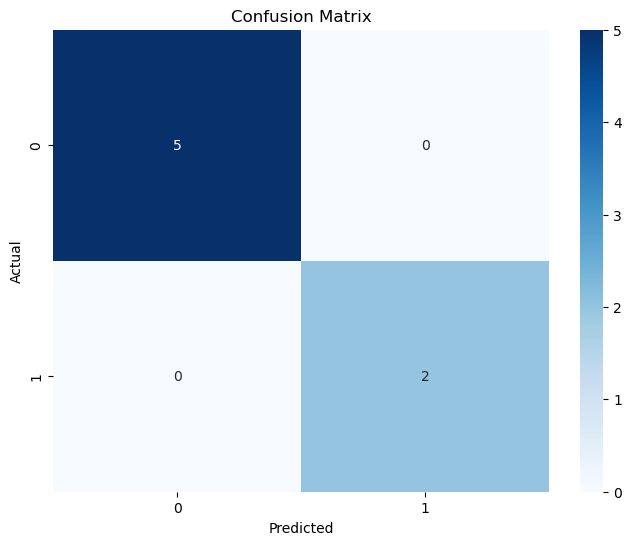

In [16]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5 DTC MODEL_ML

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [21]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


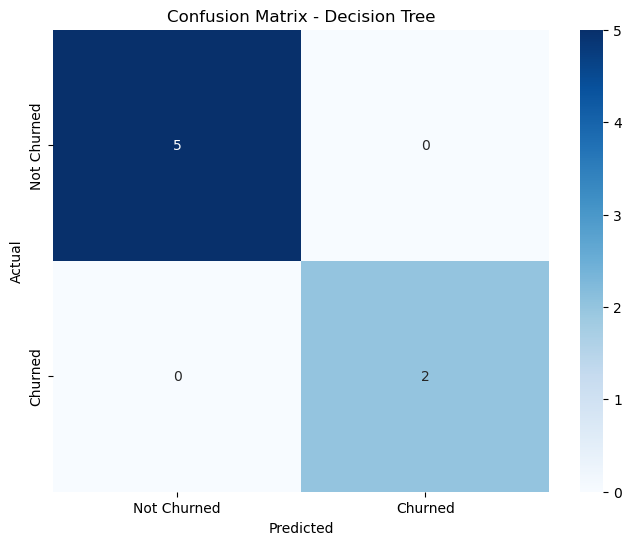

In [23]:
conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
xticklabels=["Not Churned", "Churned"],
yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 6 RFC MODEL_ML

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [28]:
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


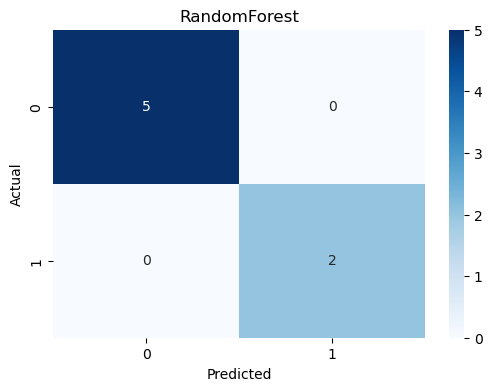

In [33]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("RandomForest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
